# Pothole Risk Model Evaluation

This notebook summarizes the current sample-data evaluation for the Bay Area Pothole AI Tracker. The numbers are useful for portfolio documentation and development checks, but they should not be treated as production validation because the bundled sample dataset is intentionally small.

## Dataset

- Historical labels: `data/sample_bay_area_311_potholes.csv`
- Environmental predictors: `data/sample_bay_area_environmental_features.csv`
- Prediction grid: `predictive-service/data/risk_grid.geojson`

The training script creates positive cells from pothole report locations and nearby negative cells from road/land areas without pothole reports.

In [ ]:
from pathlib import Path
import pandas as pd
metrics_path = Path('model_metrics.csv')
if not metrics_path.exists():
    metrics_path = Path('docs/model_metrics.csv')
metrics = pd.read_csv(metrics_path)
metrics

## Model Comparison

Best sample holdout model by ROC-AUC/F1 ordering: **Random Forest**.

| Model                  |   Accuracy |   Precision |   Recall |    F1 |   ROC-AUC |
|:-----------------------|-----------:|------------:|---------:|------:|----------:|
| Random Forest          |      0.86  |       0.75  |    0.5   | 0.6   |     0.827 |
| Hist Gradient Boosting |      0.86  |       0.8   |    0.444 | 0.571 |     0.743 |
| Decision Tree          |      0.826 |       0.636 |    0.389 | 0.483 |     0.67  |
| Logistic Regression    |      0.558 |       0.25  |    0.556 | 0.345 |     0.641 |
| Weighted Heuristic     |      0.593 |       0.27  |    0.556 | 0.364 |     0.569 |

The best model on this sample holdout split is **Random Forest** with ROC-AUC **0.827**, accuracy **0.860**, precision **0.750**, recall **0.500**, and F1 **0.600**. The next closest model by ROC-AUC is **Hist Gradient Boosting** at **0.743**. This means Random Forest is currently the strongest ranking model on the sample data, although the dataset is too small to treat this as final production evidence.

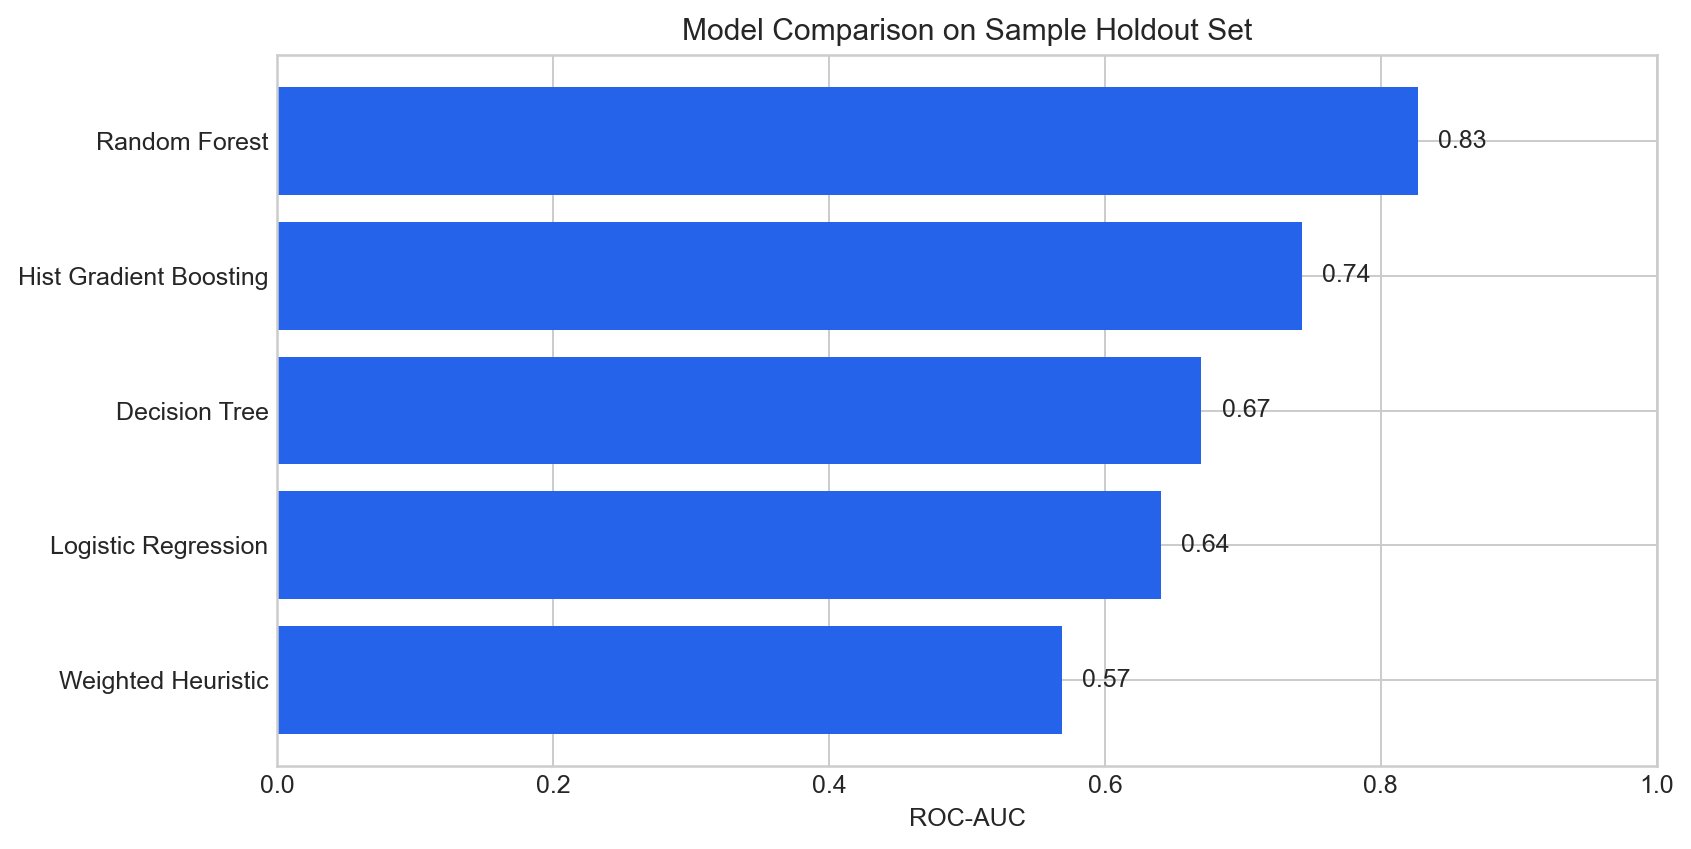

In [ ]:
# Embedded plot: Model comparison


## ROC Curve and Confusion Matrix

The ROC curve shows how well the models separate pothole and non-pothole cells across thresholds. The confusion matrix shows true and false predictions at a 0.5 threshold.

The ROC curve confirms that **Random Forest** separates pothole and non-pothole grid cells better than the other tested baselines on this sample. At the default 0.5 threshold, the confusion matrix contains **9 true positives**, **65 true negatives**, **3 false positives**, and **9 false negatives**. The low false-positive count is good for avoiding unnecessary driver warnings, but the false negatives show that recall should be improved before using the model for safety-critical alerts.

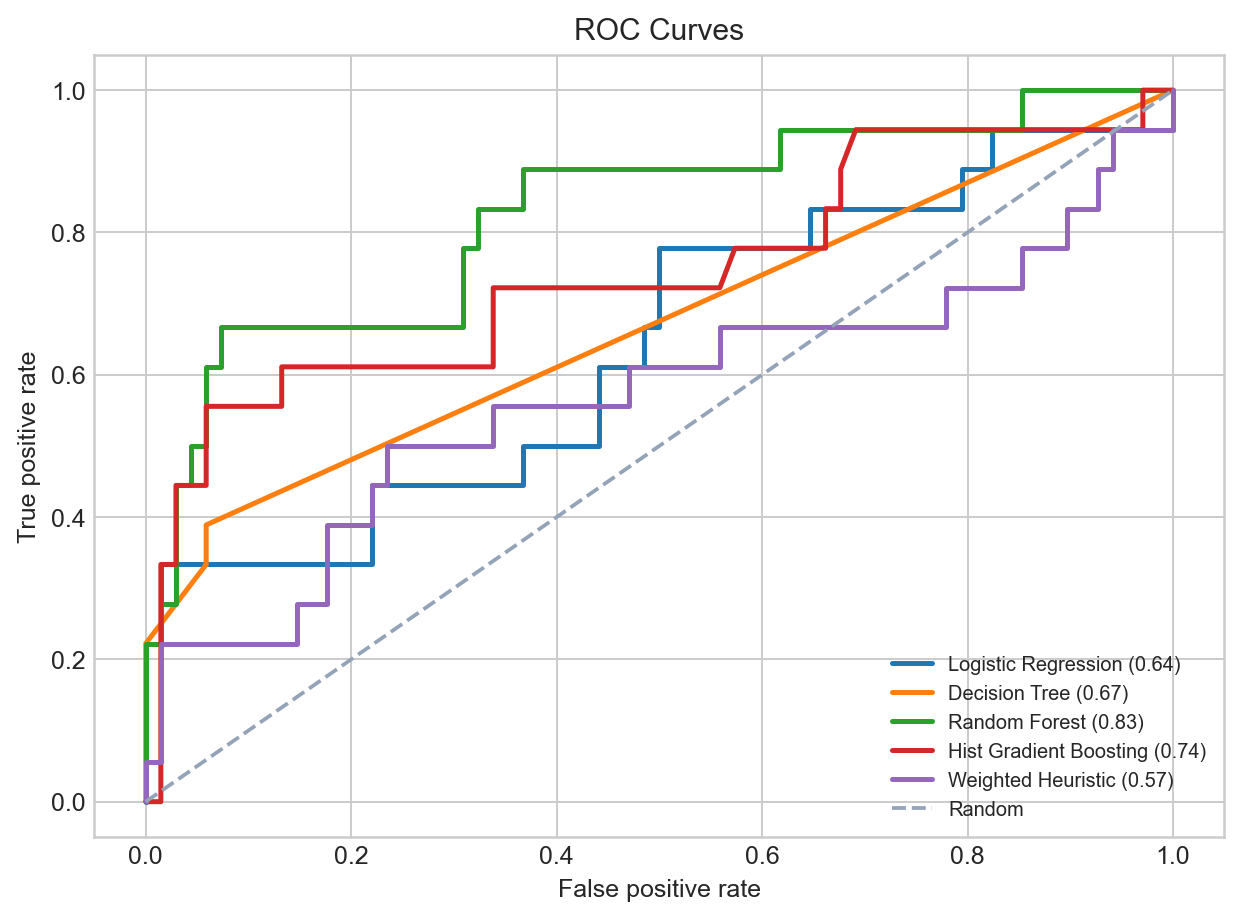

In [ ]:
# Embedded plot: ROC curve


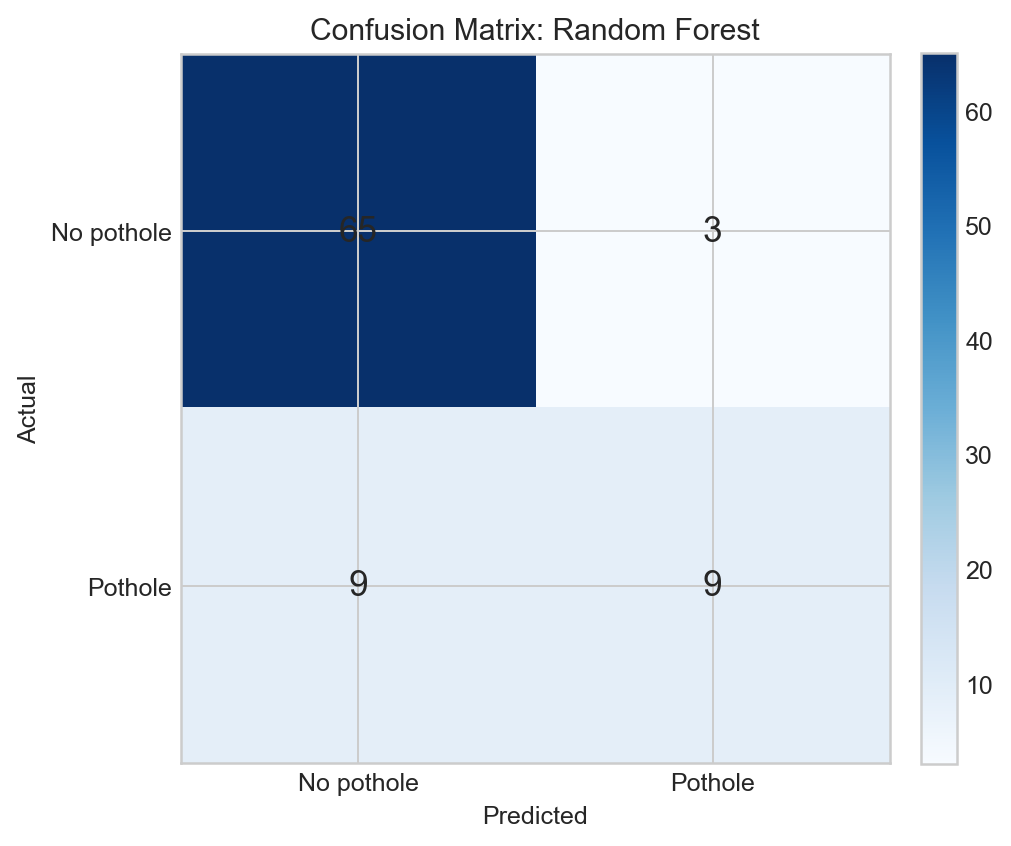

In [ ]:
# Embedded plot: Confusion matrix


## Feature Importance

Feature importance is estimated with permutation importance on the sample holdout set. This helps explain which predictors are most useful for the current model.

The most important features in this sample run are `storm_drain_density_250m` (0.26), `topographic_wetness_index` (0.14), `flood_311_count_24m` (0.13), `road_class_score` (0.12), `impervious_surface_pct` (0.09). The result is consistent with the project hypothesis: pothole risk is connected to drainage and water-retention conditions, historical flooding or 311 activity, road class, impervious surfaces, truck exposure, pavement condition, rainfall, and traffic load. These importance values should be recalculated when larger official datasets are added.

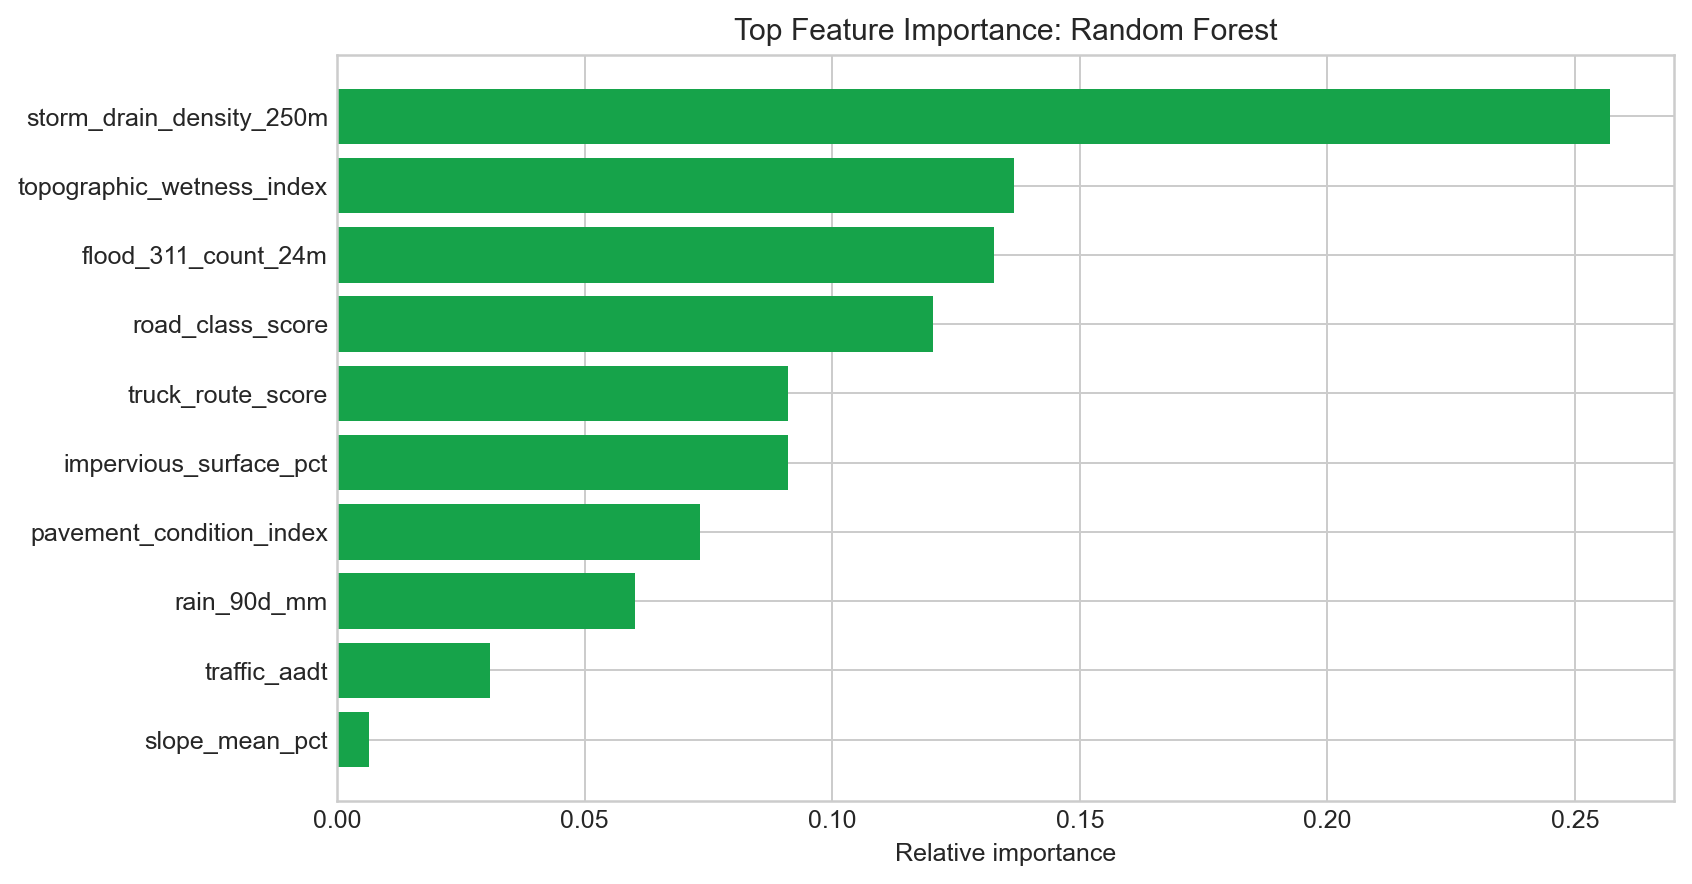

In [ ]:
# Embedded plot: Feature importance


## Risk Grid Distribution

| risk_band   |   cells |   mean_probability |
|:------------|--------:|-------------------:|
| low         |   17721 |              0.184 |
| medium      |    3159 |              0.514 |
| high        |      66 |              0.759 |

The generated Bay Area grid contains **17721 low-risk cells**, **3159 medium-risk cells**, and **66 high-risk cells**. This distribution is desirable for a prototype because it does not mark the entire region as dangerous. Instead, it keeps the highest-risk band focused on a smaller set of cells.

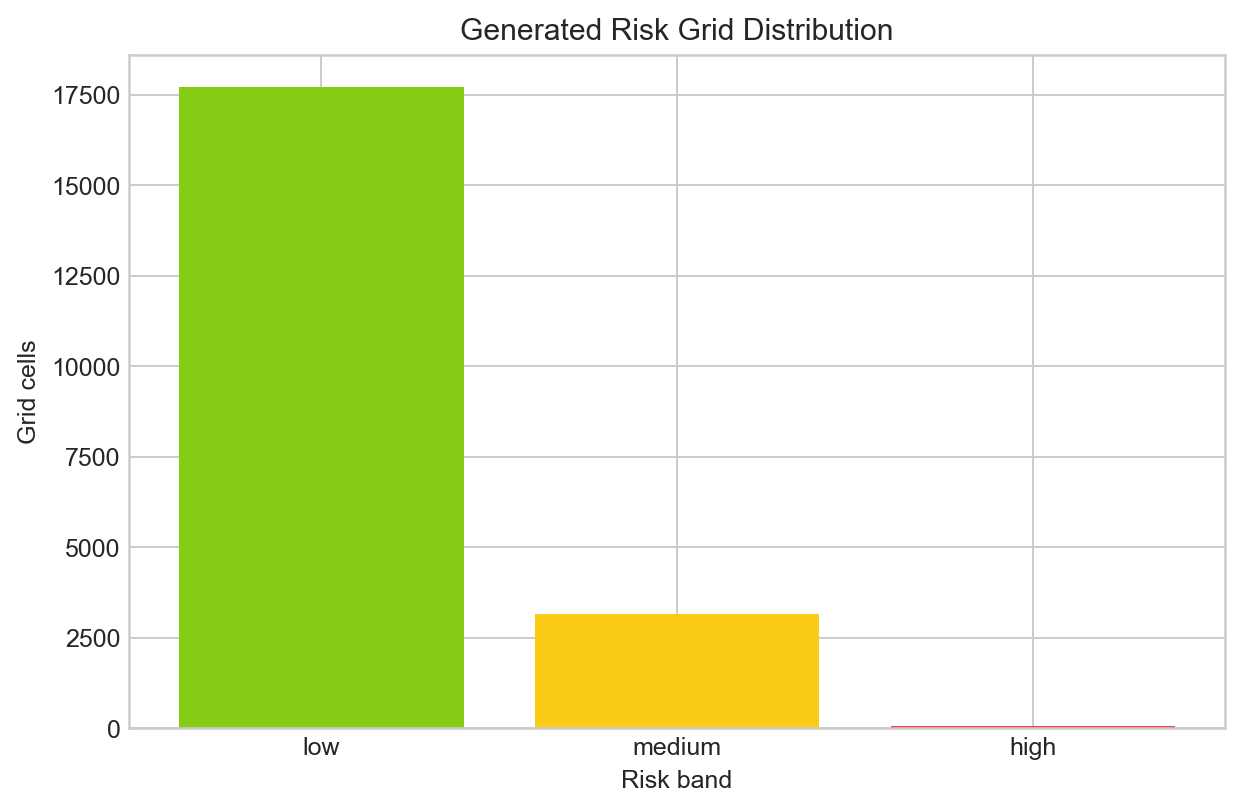

In [ ]:
# Embedded plot: Risk grid distribution


## Live vs Predicted Comparison

This chart checks where historical pothole reports fall relative to the generated prediction bands. In a production study, the same method should be repeated with future reports that were not used during training.

| risk_band   |   live_reports |   mean_probability |
|:------------|---------------:|-------------------:|
| low         |              5 |              0.31  |
| medium      |             15 |              0.601 |
| high        |              9 |              0.778 |

In the historical report comparison, **9 reports** fall in high-risk cells, **15 reports** fall in medium-risk cells, and **5 reports** fall in low-risk cells. Most matched reports are in medium or high predicted areas, which suggests that the probability surface is directionally useful. The remaining low-risk matches show where the model needs better data or threshold tuning.

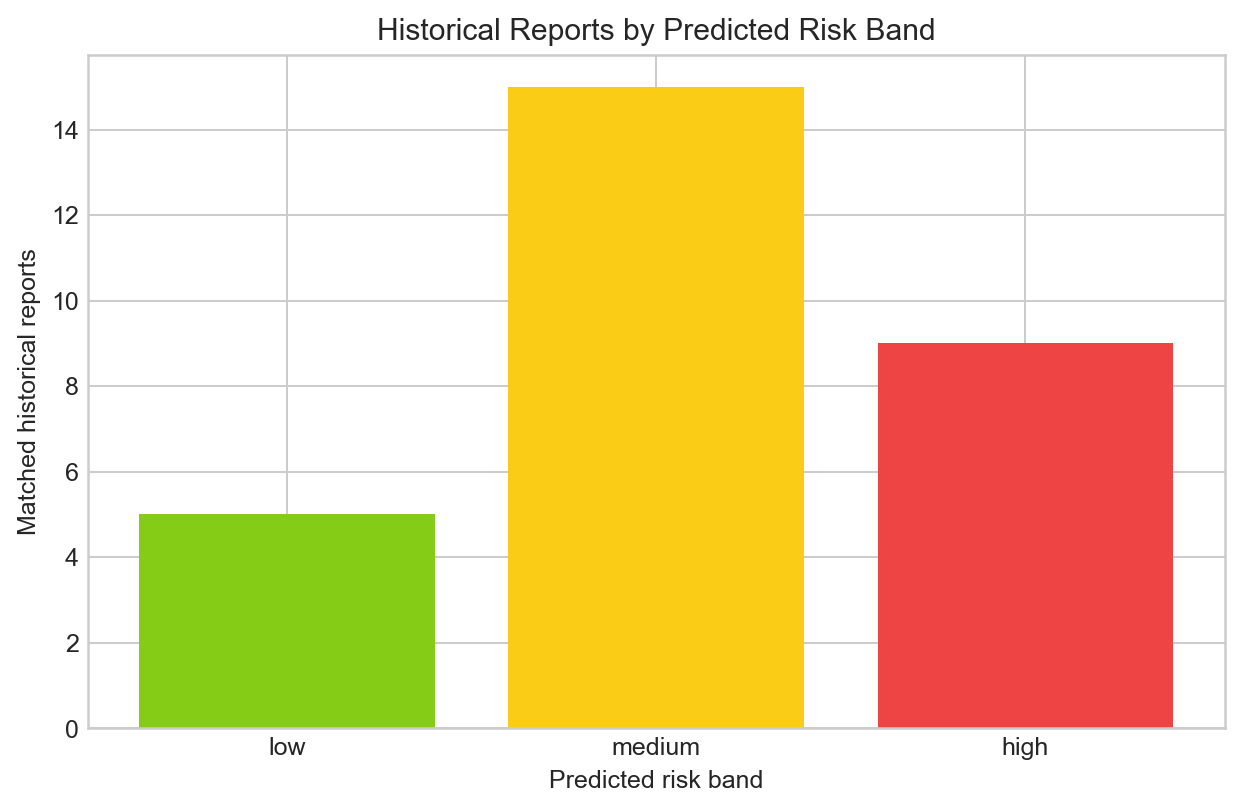

In [ ]:
# Embedded plot: Live vs predicted comparison


## Final Interpretation

Based on the current sample evaluation, **Random Forest** is the strongest candidate model for the next training iteration because it has the highest ROC-AUC (**0.827**) and the best F1 score (**0.600**) among the tested approaches. The deployed training pipeline currently uses Hist Gradient Boosting, which still performs reasonably with ROC-AUC **0.743** and precision **0.800**, but this notebook suggests that Random Forest should be tested as a production model candidate. The weighted heuristic is useful for explainability and fallback behavior, but its standalone ROC-AUC (**0.569**) is weaker than the learned models. Overall, the plots support the project design: combining live reports with drainage, rainfall, pavement, and traffic predictors creates a meaningful pothole-risk surface. The most important next step is to validate the same pipeline on a larger official dataset using a time-based split, then tune the alert threshold to increase recall without creating too many false driver warnings.